<div align="center" style="font-size: 2.5em; font-weight: bold; margin-bottom: 10px;">Diplomski rad — RAG pristup</div>

<div align="center" style="font-size: 1.2em; color: #555;">Qwen2.5-14B-Instruct &middot; multilingual-e5-large &middot; FAISS</div>

<div align="right" style="font-style: italic; color: #666;">by Zlatko Pračić</div>

## 1. Postavljanje okruženja

Instalacija biblioteka, montiranje Google Drivea, uvoz modula i autentifikacija.

In [1]:
!pip install -q -U bitsandbytes transformers accelerate sentencepiece
!pip install -q -U sentence-transformers faiss-cpu
!pip install -q python-docx pdfplumber==0.11.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 150.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 133.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 148.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 140.6 MB/s eta 0:00:00


In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline, BitsAndBytesConfig, GenerationConfig
from google.colab import userdata
from huggingface_hub import login
from sentence_transformers import SentenceTransformer
from docx import Document
import pdfplumber
import faiss
import numpy as np
import torch
import time
import pandas as pd
import os
import json
import logging
from copy import deepcopy
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import re

**Učitavanje modela**

In [4]:
# ============================================================
# OPCIJA A: čitanje LLM-a izravno s Google Drivea
# Pokreni OVU ćeliju ILI ćeliju B — ne obje.
# ============================================================

# model_name = "Qwen/Qwen2.5-14B-Instruct"
model_name = "utter-project/EuroLLM-22B-Instruct-2512"

from google.colab import drive
drive.mount('/content/drive')

os.environ["HF_HOME"] = "/content/drive/MyDrive/hf_cache"
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"

print(f"Model: {model_name}")
print(f"Čitanje s Drivea: {os.environ['HF_HOME']}")

Mounted at /content/drive
Model: utter-project/EuroLLM-22B-Instruct-2512
Čitanje s Drivea: /content/drive/MyDrive/hf_cache


In [ ]:
# ============================================================
# OPCIJA B: kopiranje LLM-a na /content (brži disk) pa čitanje
# Pokreni OVU ćeliju ILI ćeliju A — ne obje.
# ============================================================

import os

model_name = "Qwen/Qwen2.5-14B-Instruct"
# model_name = "utter-project/EuroLLM-22B-Instruct-2512"

from google.colab import drive
drive.mount('/content/drive')

hf_ime    = "models--" + model_name.replace("/", "--")
izvor     = f"/content/drive/MyDrive/hf_cache/hub/{hf_ime}"
odrediste = f"/content/hf_cache/hub/{hf_ime}"

if not os.path.exists(odrediste):
    print("Kopiranje modela na /content...")
    !mkdir -p /content/hf_cache/hub
    !cp -r {izvor} {odrediste}
    print("Gotovo.")

os.environ["HF_HOME"] = "/content/hf_cache"
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"

print(f"Model: {model_name}")
print(f"Čitanje s /content: {os.environ['HF_HOME']}")

In [5]:
token = userdata.get('HF_TOKEN')
login(token)

In [6]:
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4"
)

pipe = pipeline(
    "text-generation",
    model=model_name,
    dtype=torch.float16,
    device_map="auto",
    model_kwargs={"quantization_config": quantization_config}
)

pipe.model.generation_config.max_length = 8192

config.json:   0%|          | 0.00/680 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/40.3k [00:00<?, ?B/s]

Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/489 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/47.3k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/2.41M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/15.8M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

## 3. Embedding model i FAISS indeks

Inicijalizacija modela za vektorizaciju i FAISS indeksa za pretraživanje sličnosti.

In [7]:
_transformers_logger = logging.getLogger("transformers.modeling_utils")
_prev_level = _transformers_logger.level
_transformers_logger.setLevel(logging.ERROR)

embed_model = SentenceTransformer("intfloat/multilingual-e5-large")

_transformers_logger.setLevel(_prev_level)

modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/160k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/690 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/418 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/201 [00:00<?, ?B/s]

### Demonstracija vektorizacije — word embeddings

Da bi se razumjela vektorizacija na razini riječi, uzimamo nekoliko primjernih riječi i pretvaramo ih u numeričke vektorske reprezentacije. Semantički slične riječi trebale bi imati slične vektore.

In [8]:
example_words = [
    "king", "queen", "prince", "princess",
    "servant", "minister", "officer", "citizen",
    "dog", "cat", "tiger", "lion", "wolf",
    "apple", "orange", "banana", "grape", "strawberry",
    "automobil", "autobus", "vlak", "biciklo", "avion",
]

word_embeddings = embed_model.encode(example_words, convert_to_numpy=True).astype('float32')

print("Vektorizacija pojedinih riječi (prikaz prvih 5 dimenzija):")
for i, word in enumerate(example_words):
    print(f"\n'{word}': {word_embeddings[i, :5]}")

print(f"\nOblik embeddingsa: {word_embeddings.shape}")

Vektorizacija pojedinih riječi (prikaz prvih 5 dimenzija):

'king': [ 0.03074569  0.0134964  -0.00854846 -0.05647562  0.00892064]

'queen': [ 0.04783215  0.0100665  -0.04158695 -0.05912168  0.00088692]

'prince': [-0.01032693  0.02095075 -0.01923212 -0.0598444   0.01597854]

'princess': [-0.00585422  0.02454895 -0.01423751 -0.04114152  0.01230508]

'servant': [ 0.001856    0.00376315 -0.01744971 -0.04337291  0.00892179]

'minister': [ 0.03089253  0.00039883 -0.02489517 -0.0503465   0.01693003]

'officer': [ 0.01764584  0.00369853 -0.03449766 -0.04244428  0.01467324]

'citizen': [ 0.01106871 -0.00934679 -0.02305578 -0.03651221  0.02769204]

'dog': [ 0.01607499  0.00735521 -0.01680318 -0.02435895  0.00346138]

'cat': [ 0.01518158  0.02558515 -0.01590005 -0.02830513  0.02100921]

'tiger': [-0.00448787  0.01331295 -0.01526779 -0.01996675  0.02060821]

'lion': [ 0.00794241  0.01005744 -0.02502998 -0.04405249  0.00653131]

'wolf': [ 0.02633049  0.01427648 -0.03460052 -0.04655442 -0.00535035]

### Grafički prikaz vektorizacije (t-SNE)

Visoko-dimenzionalne vektorske reprezentacije reduciramo na 2D pomoću t-SNE metode. Semantički srodne riječi trebale bi biti grupirane zajedno.

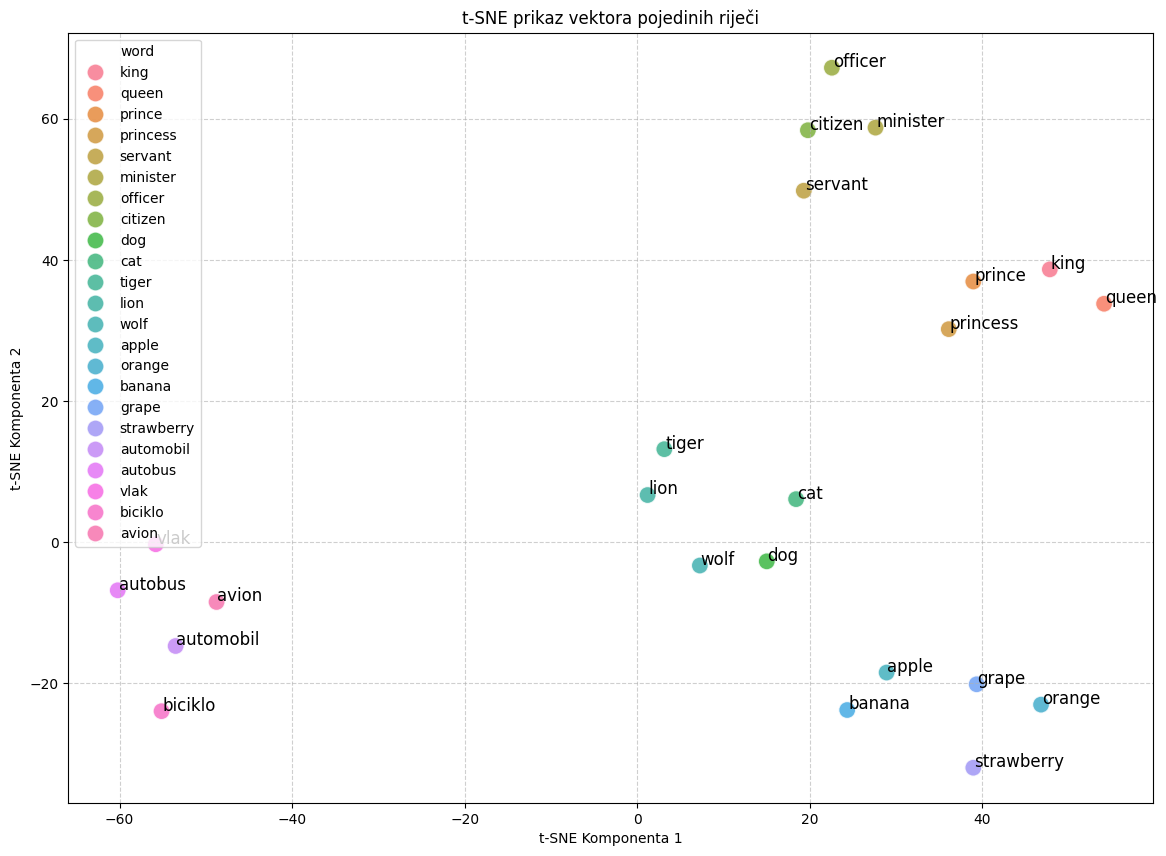

In [9]:
tsne_words = TSNE(n_components=2, random_state=42, perplexity=min(5, len(example_words) - 1))
reduced_word_embeddings = tsne_words.fit_transform(word_embeddings)

df_tsne_words = pd.DataFrame({
    'x': reduced_word_embeddings[:, 0],
    'y': reduced_word_embeddings[:, 1],
    'word': example_words
})

plt.figure(figsize=(14, 10))
sns.scatterplot(
    x='x', y='y', hue='word',
    data=df_tsne_words, legend='full', alpha=0.8, s=150
)
for i, word in enumerate(example_words):
    plt.text(df_tsne_words['x'][i] + 0.1, df_tsne_words['y'][i] + 0.1, word, fontsize=12)

plt.title('t-SNE prikaz vektora pojedinih riječi')
plt.xlabel('t-SNE Komponenta 1')
plt.ylabel('t-SNE Komponenta 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [10]:
corpus_texts = []
corpus_metadata = []

embedding_dim = embed_model.get_sentence_embedding_dimension()
faiss_index = faiss.IndexFlatIP(embedding_dim)

/tmp/ipykernel_1895/1185578560.py:4: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  embedding_dim = embed_model.get_sentence_embedding_dimension()


### Inicijalizacija FAISS indeksa i korpusa

FAISS (Facebook AI Similarity Search) je biblioteka za efikasno pretraživanje sličnih vektora. Koristimo `IndexFlatIP` (inner product) s L2 normaliziranim vektorima, što efektivno daje **cosine similarity** — optimalniju metriku za semantičko pretraživanje pravnih tekstova u usporedbi s L2 distancom.

In [11]:
def add_documents_to_corpus(texts, metadatas=None):
    global corpus_texts, corpus_metadata, faiss_index

    if metadatas is None:
        metadatas = [None] * len(texts)

    prefixed_texts = ["passage: " + t for t in texts]
    embeddings = embed_model.encode(prefixed_texts, convert_to_numpy=True, show_progress_bar=False)

    faiss.normalize_L2(embeddings)

    corpus_texts.extend(texts)
    corpus_metadata.extend(metadatas)

    faiss_index.add(embeddings)

    print(f"Dodano {len(texts)} dokumenata u RAG korpus. Ukupno: {len(corpus_texts)}")

In [12]:
def extract_text_from_docx(file_path):
    try:
        doc = Document(file_path)
        text = '\n'.join([para.text for para in doc.paragraphs])
        return text
    except Exception as e:
        print(f"Greška pri čitanju .docx: {e}")
        return None

def extract_text_from_pdf(file_path):
    try:
        text = ""
        with pdfplumber.open(file_path) as pdf:
            for page in pdf.pages:
                page_text = page.extract_text()
                if page_text:
                    text += page_text + "\n"
        return text
    except Exception as e:
        print(f"Greška pri čitanju PDF-a: {e}")
        return None

def chunk_by_articles(text, doc_name, max_chunk=1200, min_chunk_len=50):
    article_pattern = r'(Članak\s+\d+[a-z]?\.)'
    parts = re.split(article_pattern, text)

    if len(parts) <= 1:
        return chunk_text_with_overlap(text, chunk_size=800, overlap=200, min_chunk_len=min_chunk_len)

    chunks = []

    preamble = parts[0].strip()
    if len(preamble) >= min_chunk_len:
        if len(preamble) <= max_chunk:
            chunks.append(f"[{doc_name}] {preamble}")
        else:
            preamble_chunks = chunk_text_with_overlap(preamble, chunk_size=800, overlap=200, min_chunk_len=min_chunk_len)
            chunks.extend([f"[{doc_name}] {pc}" for pc in preamble_chunks])

    for i in range(1, len(parts), 2):
        header = parts[i].strip()
        body = parts[i + 1].strip() if i + 1 < len(parts) else ""
        article_text = f"{header}\n{body}"

        if len(article_text) + len(doc_name) + 3 <= max_chunk:
            if len(article_text) >= min_chunk_len:
                chunks.append(f"[{doc_name}] {article_text}")
        else:
            sub_parts = re.split(r'\n(?=\(\d+\)|\–\s|–\s)', body)
            current_sub = f"{header}"

            for sp in sub_parts:
                sp = sp.strip()
                if not sp:
                    continue
                if len(current_sub) + len(sp) + len(doc_name) + 4 <= max_chunk:
                    current_sub += "\n" + sp
                else:
                    if len(current_sub) >= min_chunk_len:
                        chunks.append(f"[{doc_name}] {current_sub}")
                    current_sub = f"{header} (nastavak)\n{sp}"

            if len(current_sub) >= min_chunk_len:
                chunks.append(f"[{doc_name}] {current_sub}")

    return chunks

def chunk_text_with_overlap(text, chunk_size=800, overlap=200, min_chunk_len=50):
    paragraphs = text.split('\n\n')
    paragraphs = [p.strip() for p in paragraphs if p.strip()]

    split_paragraphs = []
    for para in paragraphs:
        if len(para) <= chunk_size:
            split_paragraphs.append(para)
        else:
            start = 0
            while start < len(para):
                end = start + chunk_size
                if end >= len(para):
                    split_paragraphs.append(para[start:])
                    break
                space_idx = para.rfind(' ', start, end)
                if space_idx > start:
                    split_paragraphs.append(para[start:space_idx])
                    start = space_idx + 1
                else:
                    split_paragraphs.append(para[start:end])
                    start = end

    chunks = []
    current_chunk = ""

    for para in split_paragraphs:
        if len(current_chunk) + len(para) + 2 <= chunk_size:
            current_chunk = current_chunk + "\n\n" + para if current_chunk else para
        else:
            if len(current_chunk) >= min_chunk_len:
                chunks.append(current_chunk.strip())
            if overlap > 0 and current_chunk:
                overlap_text = current_chunk[-overlap:]
                space_idx = overlap_text.find(' ')
                if space_idx != -1:
                    overlap_text = overlap_text[space_idx + 1:]
                current_chunk = overlap_text + "\n\n" + para
            else:
                current_chunk = para

    if current_chunk and len(current_chunk.strip()) >= min_chunk_len:
        chunks.append(current_chunk.strip())

    return chunks

def detect_document_hierarchy(filename):
    filename_lower = filename.lower()
    if 'ustav' in filename_lower:
        return {"razina": 1, "tip_propisa": "Ustav"}
    elif 'zakon' in filename_lower:
        return {"razina": 2, "tip_propisa": "Zakon"}
    elif 'pravilnik' in filename_lower:
        return {"razina": 3, "tip_propisa": "Pravilnik"}
    else:
        return {"razina": 4, "tip_propisa": "Ostalo"}

def get_document_display_name(filename):
    name = os.path.splitext(filename)[0]
    name = name.replace('_', ' ')
    return name

## 4. Učitavanje podataka i indeksiranje

Učitavamo pitanja/odgovore iz JSON datoteke i pravne dokumente iz Google Drivea u FAISS.

In [13]:
try:
    with open('/content/drive/My Drive/diplomskiRad/pitanja_odgovori.json', 'r', encoding='utf-8') as f:
        qa_data = json.load(f)

    print(f"✓ Učitano {qa_data['metadata']['ukupno_pitanja']} pitanja i odgovora.")
    print(f"  Struktura:")
    for kategorija, info in qa_data['metadata']['struktura'].items():
        print(f"    - {kategorija}: {info['broj']} ({info['postotak']})")
except FileNotFoundError:
    print('Datoteka pitanja_odgovori.json nije pronađena na navedenoj putanji.')
    qa_data = None
except json.JSONDecodeError:
    print('Greška pri parsiranju JSON datoteke. Provjerite je li format ispravan.')
    qa_data = None

✓ Učitano 43 pitanja i odgovora.
  Struktura:
    - kompleksna_vise_dokumenata: 12 (12.9%)
    - kompleksna_jedan_dokument: 8 (12.9%)
    - jednostavna: 23 (74.2%)


In [14]:
docs_dir = '/content/drive/My Drive/diplomskiRad/Dokumenti'

if os.path.exists(docs_dir):
    print(f"Učitavam dokumente iz mape: '{docs_dir}'...\n")

    for file in os.listdir(docs_dir):
        file_path = os.path.join(docs_dir, file)
        text = None

        try:
            if file.endswith('.txt'):
                with open(file_path, 'r', encoding='utf-8') as f:
                    text = f.read()
                print(f"✓ .txt: {file}")
            elif file.endswith('.docx'):
                text = extract_text_from_docx(file_path)
                if text:
                    print(f"✓ .docx: {file}")
            elif file.endswith('.doc'):
                print(f"⚠ .doc: {file} (zahtijeva LibreOffice ili specifičnu biblioteku)")
            elif file.endswith('.pdf'):
                text = extract_text_from_pdf(file_path)
                if text:
                    print(f"✓ PDF: {file}")
            else:
                print(f"⊘ Nepoznat format: {file}")

            if text:
                hierarchy = detect_document_hierarchy(file)
                doc_name = get_document_display_name(file)

                chunks = chunk_by_articles(text, doc_name, max_chunk=1200, min_chunk_len=50)

                if chunks:
                    metadatas = [{
                        "file": file,
                        "type": file.split('.')[-1],
                        "razina": hierarchy["razina"],
                        "tip_propisa": hierarchy["tip_propisa"]
                    }] * len(chunks)

                    add_documents_to_corpus(chunks, metadatas)
                    print(f"  └─ Dodano {len(chunks)} chunkova (razina: {hierarchy['tip_propisa']})\n")
        except Exception as e:
            print(f"✗ Greška pri obradi {file}: {e}\n")
else:
    print(f"Mapa '{docs_dir}' nije pronađena!")
    print(f"Dostupne stavke: {os.listdir('.')}")

Učitavam dokumente iz mape: '/content/drive/My Drive/diplomskiRad/Dokumenti'...

✓ PDF: Pravilnik o temeljnom vojnom osposobljavanju.pdf
Dodano 24 dokumenata u RAG korpus. Ukupno: 24
  └─ Dodano 24 chunkova (razina: Pravilnik)

✓ .docx: Ustav Republike Hrvatske 2018.docx
Dodano 173 dokumenata u RAG korpus. Ukupno: 197
  └─ Dodano 173 chunkova (razina: Ustav)

✓ .docx: Zakon_o_obrani_2025.docx
Dodano 251 dokumenata u RAG korpus. Ukupno: 448
  └─ Dodano 251 chunkova (razina: Zakon)

✓ .docx: Zakon_o_sluzbi_u_Oruzanim_snagama_Republike_Hrvatske_2025.docx
Dodano 373 dokumenata u RAG korpus. Ukupno: 821
  └─ Dodano 373 chunkova (razina: Zakon)

⊘ Nepoznat format: Pravilnik o temeljnom vojnom osposobljavanju.html


In [15]:
print(f"\nStatistika RAG korporusa:")
print(f" Ukupno učitano {len(corpus_texts)} dokumenata za RAG.")
print(f" FAISS index sadrži {faiss_index.ntotal} dokumenata.")

if corpus_texts:
    print("\nPrimjeri učitanih dokumenata (prva 3):")
    for i, doc in enumerate(corpus_texts[:3], 1):
        preview = doc[:150] + "..." if len(doc) > 150 else doc
        print(f"\n   [{i}] {preview}")
else:
    print("\nNema učitanih dokumenata! Provjerite mapu 'Dokumenti'.")


Statistika RAG korporusa:
 Ukupno učitano 821 dokumenata za RAG.
 FAISS index sadrži 821 dokumenata.

Primjeri učitanih dokumenata (prva 3):

   [1] [Pravilnik o temeljnom vojnom osposobljavanju] NN 155/2025 (23.12.2025.), Pravilnik o temeljnom vojnom osposobljavanju
MINISTARSTVO OBRANE
2328
Na tem...

   [2] [Pravilnik o temeljnom vojnom osposobljavanju] Članak 1.
(1) Ovim se Pravilnikom propisuje postupak prijave i evidencije kandidata i upućivanje kandid...

   [3] [Pravilnik o temeljnom vojnom osposobljavanju] Članak 2.
Pojmovi koji se koriste u ovom Pravilniku imaju sljedeće značenje:
– kandidat je novak i osob...


## 5. RAG sustav — dohvaćanje i generacija

Funkcije za retrieval relevantnih odlomaka i generaciju odgovora LLM modelom.

In [16]:
# ============================================================
# IZMJENA RAG-1: score_threshold snizen 0.4 -> 0.30
# e5-large daje kosinusnu slicnost u uzem rasponu, pa je prag 0.4
# odbacivao valjane clanke i uzrokovao lazne "nije pronadeno".
# ============================================================
def retrieve_relevant_passages(query, top_k=5, score_threshold=0.30, rerank_top_k=None):
    if len(corpus_texts) == 0:
        return []

    fetch_k = min(top_k * 2, len(corpus_texts))

    query_embedding = embed_model.encode(["query: " + query], convert_to_numpy=True, show_progress_bar=False)

    faiss.normalize_L2(query_embedding)

    D, I = faiss_index.search(query_embedding, fetch_k)

    candidates = []
    for score, idx in zip(D[0], I[0]):
        if idx == -1:
            continue
        if score < score_threshold:
            continue
        candidates.append({
            "text": corpus_texts[idx],
            "score": float(score),
            "metadata": corpus_metadata[idx]
        })

    for c in candidates:
        if c["metadata"] is not None and "razina" in c["metadata"]:
            razina = c["metadata"]["razina"]
            hierarchy_boost = max(0, (4 - razina)) * 0.02
            c["score"] = c["score"] + hierarchy_boost

    candidates.sort(key=lambda x: x["score"], reverse=True)

    unique_results = []
    for c in candidates:
        c_words = set(c["text"].split())
        is_duplicate = False
        for existing in unique_results:
            existing_words = set(existing["text"].split())
            intersection = len(c_words & existing_words)
            union = len(c_words | existing_words)
            if union > 0 and intersection / union > 0.85:
                is_duplicate = True
                break
        if not is_duplicate:
            unique_results.append(c)

    final_k = rerank_top_k if rerank_top_k else top_k
    return unique_results[:final_k]

In [17]:
def generate_response(
    messages,
    max_new_tokens=512,
    temperature=0.5,
    do_sample=True,
    use_rag=False,
    rag_top_k=3
):
    final_messages = list(messages)

    if use_rag:
        user_query = ""
        for m in reversed(final_messages):
            if m["role"] == "user":
                user_query = m["content"]
                break

        if user_query:
            retrieved = retrieve_relevant_passages(user_query, top_k=rag_top_k)

            if len(retrieved) > 0:
                context_parts = []
                for i, r in enumerate(retrieved, start=1):
                    meta_str = ""
                    if r["metadata"] is not None and "file" in r["metadata"]:
                        meta_str = f" (izvor: {r['metadata']['file']})"
                    context_parts.append(f"[{i}] {r['text']}{meta_str}")

                context_text = "\n\n".join(context_parts)

                if final_messages and final_messages[0]["role"] == "system":
                    final_messages[0]["content"] = (
                        final_messages[0]["content"] + "\n\n"
                        "Kontekst za odgovor:\n"
                        f"{context_text}"
                    )
                else:
                    final_messages.insert(0, {
                        "role": "system",
                        "content": SYSTEM_PROMPT + f"\n\nKontekst za odgovor:\n{context_text}",
                    })

    model_max_length = getattr(pipe.tokenizer, 'model_max_length', 8192)
    if model_max_length > 100000:
      model_max_length = 8192

    input_text = pipe.tokenizer.apply_chat_template(final_messages, tokenize=False)
    input_token_count = len(pipe.tokenizer.encode(input_text))
    max_allowed_input = model_max_length - max_new_tokens

    if input_token_count > max_allowed_input:
        print(f"Upozorenje: input ({input_token_count} tokena) prelazi limit ({max_allowed_input}). Skraćujem kontekst.")
        if use_rag and final_messages and final_messages[0]["role"] == "system":
            system_content = final_messages[0]["content"]
            while input_token_count > max_allowed_input and "\n\n[" in system_content:
                last_chunk_start = system_content.rfind("\n\n[")
                system_content = system_content[:last_chunk_start]
                final_messages[0]["content"] = system_content
                input_text = pipe.tokenizer.apply_chat_template(final_messages, tokenize=False)
                input_token_count = len(pipe.tokenizer.encode(input_text))
            print(f"  Skraćeno na {input_token_count} tokena.")

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    gen_config = deepcopy(pipe.model.generation_config)
    gen_config.max_new_tokens = max_new_tokens
    gen_config.temperature = temperature
    gen_config.do_sample = do_sample
    gen_config.repetition_penalty = 1.1

    vrijeme_upita = time.time()

    response = pipe(
        final_messages,
        generation_config=gen_config,
    )

    answer = ""
    for message in response[0]['generated_text']:
        if message['role'] == 'assistant':
            answer = message['content']
            break

    stripped_answer = answer.strip()
    if not re.search(r'[.!?]$', stripped_answer) and len(stripped_answer.split()) > 5:
        last_punctuation_index = -1
        for i in range(len(stripped_answer) - 1, -1, -1):
            if stripped_answer[i] in ['.', '?', '!']:
                last_punctuation_index = i
                break

        if last_punctuation_index != -1:
            answer = stripped_answer[:last_punctuation_index + 1]
        else:
            words = stripped_answer.split()
            if len(words) > 1:
                answer = ' '.join(words[:-1]) + '...'
            elif words:
                answer = words[0]
            else:
                answer = ''
    else:
        answer = stripped_answer

    vrijeme_odgovora = time.time()
    ukupno_vrijeme = vrijeme_odgovora - vrijeme_upita

    print("Generirani odgovor:")
    print(answer)
    print(f"Ukupno vrijeme za odgovor: {ukupno_vrijeme:.2f} sekundi")

    return answer, ukupno_vrijeme

In [18]:
SYSTEM_PROMPT = (
"Ti si pravni stručnjak specijaliziran za zakonodavstvo Republike Hrvatske, posebno za Zakon o obrani, Zakon o službi u Oružanim snagama RH i pripadajuće pravilnike."
"\n\nPravila odgovaranja:"
"\n1. Jezik odgovora: hrvatski, latinica."
"\n2. Navedi konkretne članke zakona, brojčane vrijednosti i nadležna tijela."
"\n3. Ako je dostupan kontekst, koristi SAMO informacije iz njega."
"\n4. Ako kontekst ne sadržava odgovor, odgovori na temelju općeg znanja i dodaj: 'Napomena: ova informacija nije pronađena u dostupnim dokumentima."
"\n5. Odgovor neka bude koncizan i strukturiran — bez nepotrebnih uvoda."
)

In [19]:
csv_path = '/content/drive/My Drive/diplomskiRad/rezultati.csv'

## 6. Testiranje - RAG pristup

RAG pristup najprije pretražuje bazu pravnih dokumenata za relevantne odlomke, a zatim ih koristi kao kontekst pri generiranju odgovora. Očekujemo točnije i informiranije odgovore u usporedbi s Vanilla pristupom.

### RAG chat funkcija\n\nPrima kategoriju pitanja i koristi budzet konteksta (RAG_TOP_K) identican GraphRAG-u, uz izjednacene generacijske parametre (512 tokena, deterministicko dekodiranje).

In [20]:
# Budzet konteksta po kategoriji — IDENTICAN GraphRAG-u (GRAPH_TOP_K),
# da usporedba mjeri mehanizam dohvata, a ne kolicinu konteksta.
RAG_TOP_K = {
    'jednostavno':                5,
    'kompleksno_jedan_dokument':  8,
    'kompleksno_vise_dokumenata': 12,
}
RAG_TOP_K_DEFAULT = 5

# ============================================================
# IZMJENA RAG-2: budzet izlaznih tokena po kategoriji pitanja.
# Prije: fiksno 512 za sve -> kompleksni odgovori se rezali na pola
# recenice (logika rezanja na zadnju interpunkciju to je maskirala).
# Sada: jednostavna pitanja trebaju manje, visedokumentna sinteza vise.
# NAPOMENA: ovo narusava princip "identican budzet za sve". Ako ti je
# metodoloska cistoca usporedbe vaznija od izvedbe, vrati sve na 512.
# ============================================================
RAG_MAX_TOKENS = {
    'jednostavno':                384,
    'kompleksno_jedan_dokument':  640,
    'kompleksno_vise_dokumenata': 1024,
}

def rag_chat(user_question, kategorija=None):
    top_k   = RAG_TOP_K.get(kategorija, RAG_TOP_K_DEFAULT)
    max_tok = RAG_MAX_TOKENS.get(kategorija, 512)   # IZMJENA RAG-2
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": f"{user_question}\n\nOdgovori NA HRVATSKOM JEZIKU koriste\u0107i LATINICU."}
    ]
    # Deterministicko dekodiranje (do_sample=False) radi usporedivosti;
    # max_new_tokens sada ovisi o kategoriji (IZMJENA RAG-2).
    return generate_response(messages, max_new_tokens=max_tok, temperature=0.3,
                             do_sample=False, use_rag=True, rag_top_k=top_k)


### Testiranje RAG pristupa - sva pitanja

Prolazimo kroz sva pitanja iz JSON datoteke, generiramo odgovore s RAG-om i rezultate nadopunjujemo u postojece redove CSV datoteke kao nove stupce.

In [21]:
if qa_data is None:
    print("QA datoteka nije ucitana.")
else:
    df_rezultati = pd.read_csv(csv_path, encoding='utf-8-sig')

    # Mapiranje JSON kategorija -> RAG_TOP_K kljucevi (isto kao GraphRAG)
    KATEGORIJA_MAP = {
        'jednostavna_pitanja':                'jednostavno',
        'kompleksna_pitanja_jeden_dokument':  'kompleksno_jedan_dokument',
        'kompleksna_pitanja_vise_dokumenata': 'kompleksno_vise_dokumenata',
    }

    all_questions = []
    all_categories = []
    for key, value in qa_data.items():
        if key != 'metadata' and isinstance(value, list):
            for item in value:
                all_questions.append(item)
                all_categories.append(KATEGORIJA_MAP.get(key, key))

    rag_odgovori = []
    rag_vremena = []

    for i, (qa_item, kategorija) in enumerate(zip(all_questions, all_categories)):
        user_question = qa_item.get('pitanje', qa_item.get('question', ''))

        print(f"\n{'='*80}")
        print(f"Pitanje {i + 1}/{len(all_questions)}: {user_question}")
        print(f"Kategorija: {kategorija} (top_k={RAG_TOP_K.get(kategorija, RAG_TOP_K_DEFAULT)})")
        print(f"{'='*80}")

        answer, vrijeme = rag_chat(user_question, kategorija=kategorija)

        rag_odgovori.append(answer)
        rag_vremena.append(round(vrijeme, 2))

    df_rezultati['rag_odgovor'] = rag_odgovori
    df_rezultati['rag_vrijeme_sekunde'] = rag_vremena
    df_rezultati.to_csv(csv_path, index=False, encoding='utf-8-sig')
    print(f"\n{'='*80}")
    print(f"RAG rezultati nadopunjeni u: {csv_path}")
    print(f"Ukupno obradeno pitanja: {len(rag_odgovori)}")
    print(f"Prosjecno vrijeme po pitanju: {sum(rag_vremena)/len(rag_vremena):.2f} sekundi")


[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
[transformers] Both `max_new_tokens` (=1024) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Pitanje 1/43: Opišite cjelokupnu proceduru transformacije novaka u razvrstanog pričuvnika kroz sve pravne akte koji reguliraju taj proces.
Kategorija: kompleksno_vise_dokumenata (top_k=12)


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer LlamaTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
[transformers] Both `max_new_tokens` (=1024) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generirani odgovor:
Transformacija novaka u razvrstanog pričuvnika regulirana je Zakonom o obrani 2025. Ovaj proces uključuje nekoliko ključnih koraka:

1. **Ocjena sposobnosti**  
   *(Članak 25. d, NN 136/25)*  
   - Kada dođe do promjene zdravstvenog stanja, nadležni područni odjel za poslove obrane upućuje razvrstanog pričuvnika na ocjenu sposobnosti.  
   - Ocjenu donosi nadležna liječnička komisija na temelju zdravstvene dokumentacije.  
   - Ako dokumentacija nije dovoljna, traži se dodatna dokumentacija.  
   - Rezultat se unosi u vojnu iskaznicu.

2. **Dodjela vojne stručne specijalnosti**  
   *(Članak 25. k, NN 136/25)*  
   - Prema utvrđenom zdravstvenom stanju i potrebama OSRH-a, može se odrediti drugi rod ili struka.

3. **Registracija u vojnu evidenciju**  
   *(Članak 21. h, NN 136/25)*  
   - Nakon ocjene sposobnosti, osoba se upisuje u evidenciju.  
   - Ako je ocijenjena nesposobnom, moguće je pozvati na reviziju.

4. **Suradnja s diplomatskim tijelima**  
   *(Člana

[transformers] Both `max_new_tokens` (=1024) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Generirani odgovor:
Minimalno trajanje godišnjeg odmora djelatne vojne osobe iznosi **četiri tjedna** (20 radnih dana), kako je definirano u **Članku 156. stavku 1.** Zakona o službi u Oružanim snagama Republike Hrvatske 2025.  

Iznimno, ako se radi o osobi koja se prvi put zapošljava ili ima prekid duži od osam dana između dvaju zaposlenja, pravo na godišnji odmor stječe nakon šest mjeseci neprekidne službe (vidi **Članak 156. stavak 5.**).  

Za dodatne informacije o povećanju trajanja godišnjeg odmora prema posebnim kriterijima pogledajte **Članak 156. stavak 2.** istog zakona.
Ukupno vrijeme za odgovor: 22.32 sekundi

Pitanje 41/43: Koliko dana plaćenog dopusta pripada djelatnoj vojnoj osobi u slučaju rođenja djeteta?
Kategorija: jednostavno (top_k=5)


[transformers] Both `max_new_tokens` (=384) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generirani odgovor:
Djelatna vojna osoba ima pravo na **sedam radnih dana** plaćenog dopusta u slučaju rođenja djeteta (Zakon o službi u Oružanim snagama Republike Hrvatske 2025, članak 159., stavak 1.).
Ukupno vrijeme za odgovor: 7.54 sekundi

Pitanje 42/43: Koliko dana plaćenog dopusta pripada djelatnoj vojnoj osobi u slučaju zaključenja braka?
Kategorija: jednostavno (top_k=5)


[transformers] Both `max_new_tokens` (=384) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generirani odgovor:
Djelatnoj vojnoj osobi u slučaju zaključenja braka pripada **sedam radnih dana** plaćenog dopusta, prema članku 159. stavku (1) točki "a" Zakona o službi u Oružanim snagama Republike Hrvatske 2025.
Ukupno vrijeme za odgovor: 8.40 sekundi

Pitanje 43/43: Što je vojna iskaznica i tko ju izdaje?
Kategorija: jednostavno (top_k=5)
Generirani odgovor:
Vojna iskaznica je javna isprava kojom vojni obveznik dokazuje identitet dok izvršava vojnu obvezu.  
**Izdaje je:**  
- **Nadležni područni odjel za poslove obrane** (stavak 3. Čl. 25. ZOO 2025),  
ili **postrojba Oružanih snaga razine samostalne bojne, njoj ravne ili više razine** (stavak 4. Čl. 25. ZOO 2025).  

Izvori:  
- [Zakon o obrani 2025], Članak 25. (https://www.nacionalnadrzavaprava.
Ukupno vrijeme za odgovor: 20.56 sekundi

RAG rezultati nadopunjeni u: /content/drive/My Drive/diplomskiRad/rezultati.csv
Ukupno obradeno pitanja: 43
Prosjecno vrijeme po pitanju: 39.16 sekundi
